<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/DRL_PyFlyt_3d_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Graph of multiple states from the e2e execution.


## What to upload

**One file**: `models_for_3d.zip` (18 MB). Contains all 9 SB3 model checkpoints flat at the zip root: `PPO_seed{0,1,2}.zip`, `SAC_seed{0,1,2}.zip`, `TQC_seed{0,1,2}.zip`.

## Best execution

**TQC** was the only model that reached the **destination**, flying by the waypoints defined by the simulator. That was the only successful run (**1,1%**).

## 1. Install dependencies

**Highly important due to PyFlyt preference!**

Numpy is pinned to `>=2.0,<2.1` because PyFlyt's numba dependency requires it. Kernel restart at the end is intentional — the "Your session crashed" message is expected. PyBullet may compile from source if Colab is on Python 3.12+ (~8 min); pure Python deps finish in ~30s after.

In [ ]:
!python --version
!pip install --progress-bar on PyFlyt stable-baselines3 sb3-contrib gymnasium
!pip install --force-reinstall --progress-bar on "numpy>=2.0,<2.1"

import os
print("\nRestarting kernel — run the NEXT cell after restart.")
os._exit(0)

Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 32.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 62.3 MB/s eta 0:00:00
  Created wheel for pybullet: filename=pybullet-3.2.7-cp312-cp312-linux_x86_64.whl size=99873173 sha256=6e348eab4a6bdd4253dbfe7982805ce41e96e8bef3f88821967bed345844c9f9
  Stored in directory: /root/.cache/pip/wheels/72/95/1d/b336e5ee612ae9a019bfff4dc0bedd100ee6f0570db205fdf8
Successfully built pybul

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 71.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyflyt 0.29.0 requires numpy<2.0.0, but you have numpy 2.0.2 which is incompatible.


## 2. Imports & config

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import gymnasium as gym

import PyFlyt.gym_envs  # noqa: F401
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.monitor import Monitor
from sb3_contrib import TQC

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"NumPy:  {np.__version__}")


def _autodetect_env_id():
    candidates = [
        "PyFlyt/Fixedwing-Waypoints-v3",
        "PyFlyt/Fixedwing-Waypoints-v2",
        "PyFlyt/Fixedwing-Waypoints-v1",
        "PyFlyt/Fixedwing-Waypoints-v0",
    ]
    registered = set(gym.envs.registry.keys())
    for env_id in candidates:
        if env_id in registered:
            return env_id
    raise RuntimeError("No PyFlyt Fixedwing-Waypoints env found.")


ENV_ID = _autodetect_env_id()
print(f"Env:    {ENV_ID}")

ROOT = Path("./drl_pyflyt_runs")
MODEL_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
for d in (MODEL_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

ALGO_REGISTRY = {"PPO": PPO, "SAC": SAC, "TQC": TQC}
palette = {"PPO": "#1f77b4", "SAC": "#2ca02c", "TQC": "#d62728"}

Device: cuda
NumPy:  2.0.2
Env:    PyFlyt/Fixedwing-Waypoints-v3


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 3. Wrappers & smoke test

PyFlyt stores its `Aviary` (the simulator) on `inner.env` rather than `inner.aviary` — this trips up the obvious naming. The wrapper handles both. Smoke test must print `OK` before continuing.

In [2]:
class FixedwingObsWrapper(gym.ObservationWrapper):
    """Flatten PyFlyt Dict obs (attitude + Sequence of target_deltas) into a flat Box."""

    def __init__(self, env, num_future_waypoints=3):
        super().__init__(env)
        self.num_future_waypoints = num_future_waypoints
        attitude_dim = env.observation_space["attitude"].shape[0]
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(attitude_dim + 3 * num_future_waypoints,),
            dtype=np.float32,
        )

    def observation(self, obs):
        attitude = np.asarray(obs["attitude"], dtype=np.float32)
        targets = obs["target_deltas"]
        flat = np.zeros((self.num_future_waypoints, 3), dtype=np.float32)
        if len(targets) > 0:
            arr = np.asarray(targets[:self.num_future_waypoints], dtype=np.float32)
            flat[:len(arr)] = arr
        return np.concatenate([attitude, flat.flatten()])


def make_base_env():
    return Monitor(FixedwingObsWrapper(gym.make(ENV_ID)))


class TrajectoryWrapper(gym.Wrapper):
    """Records 3D position and outcome flags per episode."""

    def __init__(self, env):
        super().__init__(env)
        self._reset_buffers()

    def _reset_buffers(self):
        self.positions = []
        self.actions = []
        self.last_info = {}

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._reset_buffers()
        self._capture_position()
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.actions.append(np.asarray(action, dtype=np.float32).copy())
        self._capture_position()
        self.last_info = info
        return obs, reward, terminated, truncated, info

    def _capture_position(self):
        inner = self.env.unwrapped
        # PyFlyt stores the Aviary on inner.env (not inner.aviary)
        aviary = getattr(inner, "env", None) or getattr(inner, "aviary", None)
        if aviary is None:
            return
        try:
            arr = np.asarray(aviary.state(0), dtype=np.float32)
            if arr.ndim == 2 and arr.shape == (4, 3):
                self.positions.append(arr[3].copy())
            elif arr.ndim == 1 and arr.size >= 12:
                self.positions.append(arr[9:12].copy())
        except Exception:
            pass


def parse_episode_outcome(info):
    return {
        "env_complete": bool(info.get("env_complete", False)),
        "num_targets_reached": int(info.get("num_targets_reached", 0)),
        "collision": bool(info.get("collision", False)),
        "out_of_bounds": bool(info.get("out_of_bounds", False)),
    }


# Smoke test
print("Smoke test (random actions, 20 steps)...")
_env = TrajectoryWrapper(make_base_env())
_env.reset(seed=0)
for _ in range(20):
    _, _, term, trunc, _ = _env.step(_env.action_space.sample())
    if term or trunc:
        break
_env.close()
print(f"  captured {len(_env.positions)} positions")
assert _env.positions, "Position capture broken"
print(f"  first xyz = {_env.positions[0]}")
print(f"  last  xyz = {_env.positions[-1]}")
print("  OK")

Smoke test (random actions, 20 steps)...
                             
  captured 21 positions
  first xyz = [1.6626885 0.        9.99036  ]
  last  xyz = [15.523215    0.27798954  8.931845  ]
  OK


## 4. Load uploaded models

Drag `models_for_3d.zip` into the Colab **before** running this cell. The cell extracts it into `MODEL_DIR`. The zip is built with Python's `zipfile` so no rename trick needed.

In [3]:
import shutil
import zipfile

ZIP_NAME = "models_for_3d.zip"
src = Path(ZIP_NAME)
if not src.exists():
    raise FileNotFoundError(
        f"{ZIP_NAME} not found at /content/. "
        f"Drag it into the Colab file sidebar and re-run this cell."
    )

with zipfile.ZipFile(src) as zf:
    for name in zf.namelist():
        if name.endswith(".zip"):
            target = MODEL_DIR / Path(name).name
            with zf.open(name) as fsrc, open(target, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst)

models = sorted(MODEL_DIR.glob("*.zip"))
print(f"{len(models)} models in {MODEL_DIR}:")
for p in models:
    print(f"  {p.name}")
assert len(models) >= 3, "Need at least one model per algo"

9 models in drl_pyflyt_runs/models:
  PPO_seed0.zip
  PPO_seed1.zip
  PPO_seed2.zip
  SAC_seed0.zip
  SAC_seed1.zip
  SAC_seed2.zip
  TQC_seed0.zip
  TQC_seed1.zip
  TQC_seed2.zip


## 5. Render the 3D plot

* Visual of all the models, in random seeds (and executions).
* Visual of the TQC model (random) passing from one waypoint and crashing.
* Visual of the only success from all the models (TQC) passing from all the waypoints and reaching the target.

9 best-models in drl_pyflyt_runs/models_best:
  PPO_seed0.zip
  PPO_seed1.zip
  PPO_seed2.zip
  SAC_seed0.zip
  SAC_seed1.zip
  SAC_seed2.zip
  TQC_seed0.zip
  TQC_seed1.zip
  TQC_seed2.zip

Running PPO (best) from PPO_seed0.zip...
                             
  steps=3603 targets=0 complete=False collision=False oob=False
Running SAC (best) from SAC_seed0.zip...
                             
  steps=497 targets=0 complete=False collision=True oob=False
Running TQC (best) from TQC_seed0.zip...
                             
  steps=247 targets=0 complete=False collision=True oob=False


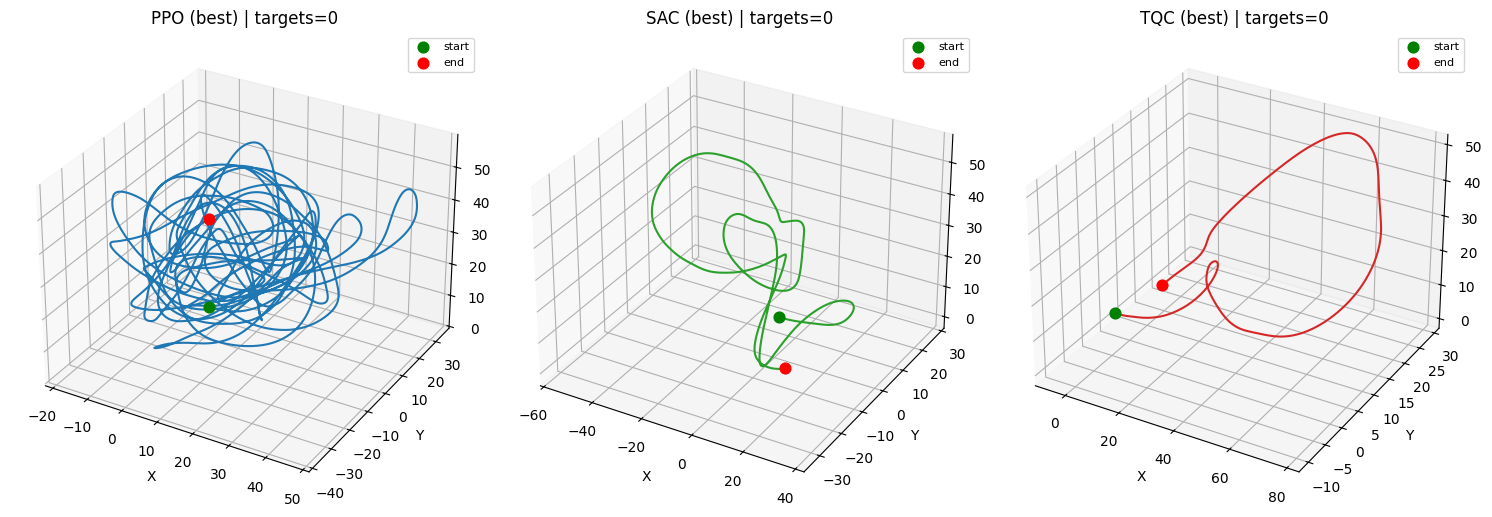


Saved: drl_pyflyt_runs/results/trajectories_3d_best.png


In [6]:
# === 3D plot using BEST-during-training checkpoints ===
import shutil
import zipfile

BEST_ZIP = "best_models_for_3d.zip"
BEST_DIR = ROOT / "models_best"
BEST_DIR.mkdir(parents=True, exist_ok=True)

src = Path(BEST_ZIP)
if not src.exists():
    raise FileNotFoundError(
        f"{BEST_ZIP} not found at /content/. "
        f"Drag it into the Colab file sidebar and re-run."
    )

# Extract (clean any old copies first so seed counts are accurate)
for old in BEST_DIR.glob("*.zip"):
    old.unlink()
with zipfile.ZipFile(src) as zf:
    for name in zf.namelist():
        if name.endswith(".zip"):
            target = BEST_DIR / Path(name).name
            with zf.open(name) as fsrc, open(target, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst)

models = sorted(BEST_DIR.glob("*.zip"))
print(f"{len(models)} best-models in {BEST_DIR}:")
for p in models:
    print(f"  {p.name}")
print()

# Render
fig = plt.figure(figsize=(15, 5))
for idx, algo in enumerate(["PPO", "SAC", "TQC"]):
    candidates = sorted(BEST_DIR.glob(f"{algo}_seed*.zip"))
    if not candidates:
        print(f"No {algo} best-model — skipping")
        ax = fig.add_subplot(1, 3, idx + 1, projection="3d")
        ax.set_title(f"{algo} | (no model)")
        continue

    print(f"Running {algo} (best) from {candidates[0].name}...")
    traj, info = collect_one_trajectory(str(candidates[0]), algo, seed=99)
    print(f"  steps={len(traj)} targets={info['num_targets_reached']} "
          f"complete={info['env_complete']} collision={info['collision']} oob={info['out_of_bounds']}")

    ax = fig.add_subplot(1, 3, idx + 1, projection="3d")
    if traj.shape[0] >= 2:
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                color=palette[algo], linewidth=1.5)
        ax.scatter(*traj[0], color="green", s=60, label="start")
        ax.scatter(*traj[-1], color="red", s=60, label="end")
        ax.legend(fontsize=8)
    else:
        ax.text2D(0.5, 0.5, "no positions", transform=ax.transAxes, ha="center")

    title = f"{algo} (best) | targets={info['num_targets_reached']}"
    if info["env_complete"]:
        title += " ✓ SOLVED"
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

plt.tight_layout()
out = RESULTS_DIR / "trajectories_3d_best.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"\nSaved: {out}")


Loading TQC_seed0.zip...
                             

WHAT THIS EPISODE LOOKED LIKE
  Goal              : fly through 4 waypoints in order
  Waypoints reached : 1 / 4
  Episode complete  : False  (True only if all 4 reached)
  Crashed           : True
  Out of bounds     : False
  Episode length    : 594 simulator steps

Waypoints (in order, world coordinates):
  WP1: (  28.1,    1.1,   32.0) <-- REACHED
  WP2: (  21.1,    9.1,   50.3)
  WP3: ( -81.4,   -6.1,   19.2)
  WP4: (  -7.6,    1.3,   21.6)



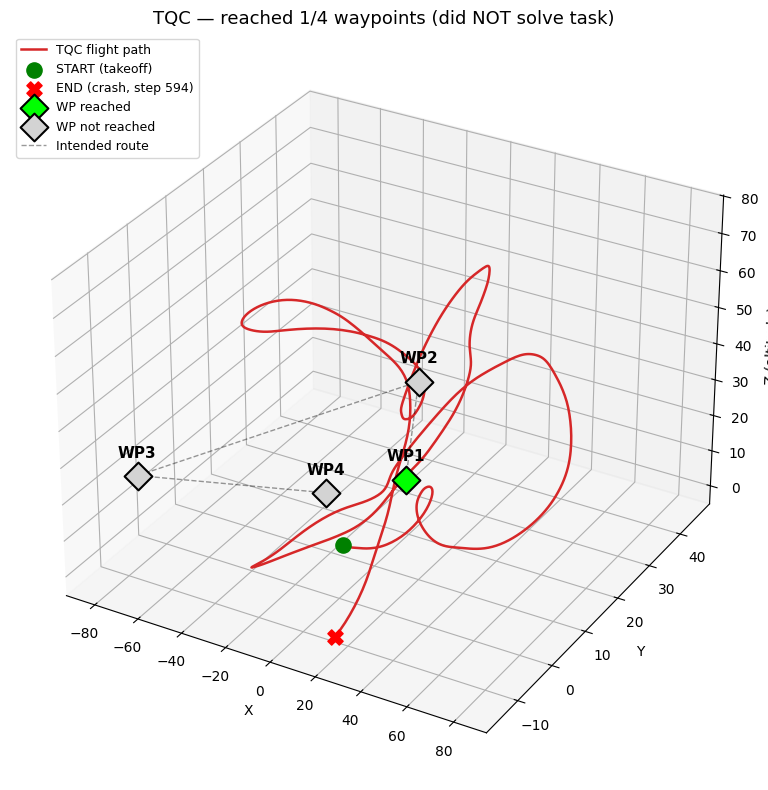

Saved: drl_pyflyt_runs/results/trajectories_3d_TQC_only.png


In [8]:
# === Simple TQC-only plot with clear labels ===
import numpy as np

# Run one episode with TQC
candidates = sorted(MODEL_DIR.glob("TQC_seed*.zip"))
model_path = str(candidates[0])
print(f"Loading {candidates[0].name}...")
traj, info, targets = collect_one_trajectory_with_targets(model_path, "TQC", seed=99)

# === Plain-English summary ===
n_total = len(targets) if targets is not None else 0
n_reached = info["num_targets_reached"]
print()
print("=" * 60)
print("WHAT THIS EPISODE LOOKED LIKE")
print("=" * 60)
print(f"  Goal              : fly through {n_total} waypoints in order")
print(f"  Waypoints reached : {n_reached} / {n_total}")
print(f"  Episode complete  : {info['env_complete']}  (True only if all {n_total} reached)")
print(f"  Crashed           : {info['collision']}")
print(f"  Out of bounds     : {info['out_of_bounds']}")
print(f"  Episode length    : {len(traj)} simulator steps")
print()

if targets is not None:
    print("Waypoints (in order, world coordinates):")
    for i, t in enumerate(targets):
        marker = " <-- REACHED" if i < n_reached else ""
        print(f"  WP{i+1}: ({t[0]:6.1f}, {t[1]:6.1f}, {t[2]:6.1f}){marker}")
print()

# === Single 3D plot ===
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Trajectory
ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
        color="#d62728", linewidth=1.8, label="TQC flight path")
ax.scatter(*traj[0], color="green", s=120, label="START (takeoff)")
ax.scatter(*traj[-1], color="red", s=120, marker="X",
           label=f"END (crash, step {len(traj)})")

# Waypoints — green if reached, gray if not
if targets is not None:
    for i, t in enumerate(targets):
        reached = i < n_reached
        ax.scatter(*t, color="lime" if reached else "lightgray",
                   marker="D", s=200, edgecolor="black", linewidth=1.5,
                   label=("WP reached" if reached and i == 0 else
                          ("WP not reached" if not reached and i == n_reached else None)))
        ax.text(t[0], t[1], t[2] + 5, f"WP{i+1}",
                fontsize=11, fontweight="bold", ha="center")
    # Dashed line: the route the plane was supposed to follow
    ax.plot(targets[:, 0], targets[:, 1], targets[:, 2],
            color="black", linestyle="--", linewidth=1, alpha=0.4,
            label="Intended route")

ax.set_title(f"TQC — reached {n_reached}/{n_total} waypoints "
             f"({'SOLVED' if info['env_complete'] else 'did NOT solve task'})",
             fontsize=13)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z (altitude)")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
out = RESULTS_DIR / "trajectories_3d_TQC_only.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")


Loading TQC_seed0.zip, resetting env with seed=10010...
                             

RESULT
  Waypoints reached : 4 / 4
  Episode complete  : True   <-- the SOLVE
  Crashed           : False
  Out of bounds     : False
  Episode length    : 362 steps

Waypoints:
  WP1: (  -6.6,   -6.7,   30.5)  <-- REACHED
  WP2: (  33.3,    8.9,   29.3)  <-- REACHED
  WP3: (   4.5,   29.6,   31.4)  <-- REACHED
  WP4: (   2.3,   -0.1,   44.1)  <-- REACHED



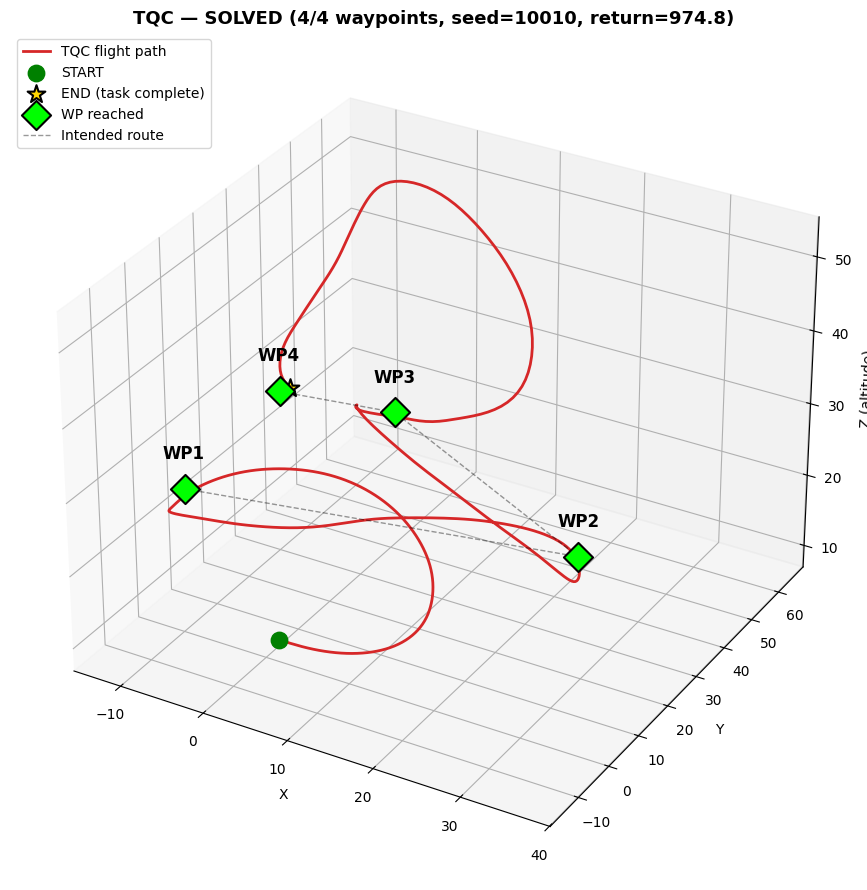

Saved: drl_pyflyt_runs/results/trajectories_3d_TQC_SOLVED.png


In [9]:
# === The ONE episode TQC solved the task ===
SOLVED_MODEL = "TQC_seed0.zip"
SOLVED_SEED = 10010

print(f"Loading {SOLVED_MODEL}, resetting env with seed={SOLVED_SEED}...")
traj, info, targets = collect_one_trajectory_with_targets(
    str(MODEL_DIR / SOLVED_MODEL), "TQC", seed=SOLVED_SEED
)

print()
print("=" * 60)
print("RESULT")
print("=" * 60)
print(f"  Waypoints reached : {info['num_targets_reached']} / {len(targets)}")
print(f"  Episode complete  : {info['env_complete']}   <-- the SOLVE")
print(f"  Crashed           : {info['collision']}")
print(f"  Out of bounds     : {info['out_of_bounds']}")
print(f"  Episode length    : {len(traj)} steps")
print()
print("Waypoints:")
for i, t in enumerate(targets):
    print(f"  WP{i+1}: ({t[0]:6.1f}, {t[1]:6.1f}, {t[2]:6.1f})  <-- REACHED")
print()

# Plot
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
        color="#d62728", linewidth=2.0, label="TQC flight path")
ax.scatter(*traj[0], color="green", s=140, label="START")
ax.scatter(*traj[-1], color="gold", s=180, marker="*",
           edgecolor="black", linewidth=1.5, label="END (task complete)")

for i, t in enumerate(targets):
    ax.scatter(*t, color="lime", marker="D", s=220,
               edgecolor="black", linewidth=1.5,
               label="WP reached" if i == 0 else None)
    ax.text(t[0], t[1], t[2] + 4, f"WP{i+1}",
            fontsize=12, fontweight="bold", ha="center")

# Intended-route dashed line
ax.plot(targets[:, 0], targets[:, 1], targets[:, 2],
        color="black", linestyle="--", linewidth=1, alpha=0.4,
        label="Intended route")

ax.set_title(f"TQC — SOLVED (4/4 waypoints, seed={SOLVED_SEED}, return={974.8:.1f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z (altitude)")
ax.legend(loc="upper left", fontsize=10)

plt.tight_layout()
out = RESULTS_DIR / "trajectories_3d_TQC_SOLVED.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")
